# Simplified soiling model simulation for Dagget 50MW Flat Plate for PROMETHEUS tests


In [1]:
import heliosoil.base_models as smb
import heliosoil.field_models as smf
import heliosoil.utilities as smu
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

d = "flat_dagget_50_soiling/"
file_params = d+"parameters.xlsx"
file_weather = d+'data.xlsx'

file_SF = d+'flat-daggett-50_for_sp_gui.csv'             
climate_file = d+'USA CA Daggett (TMY2).csv'    # only used for optical efficiency computation

output_file = "TMY_soiling_simulations.xlsx"

n_trucks = 1       # number of trucks
n_cleans = 10        # number of cleanings in time interval
cleaning_rate = 200  # heliostats cleaned per truck per day used to control sectorisation of heliostat field, leave blank to calculate using parameter values
sun_az_num,sun_el_num = 10,10   # resolution of sun angles for soiling calculations, in degrees
aoi_model,d = 'second_surface',None
# aoi_model,d = 'heimsath',0.5

c:\Users\cholette\.virtualenvs\prometheus\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading data from flat_dagget_50_soiling/parameters.xlsx ... 

Importing constants
Using config specified cleaning rate: 200.0 heliostats/shift
Grid size: 4 x 5 = 20 sectors
Sectors per truck: 6
Effective cleaning rate: 196.8 heliostats/shift
Error from target: 1.6%
Sectorizing with 5 angular and 4 radial sectors
Sectorizing field into 4 x 5 sectors ... 
Importing site data from flat_dagget_50_soiling/data.xlsx, dust_type=PM10, length=364 days
Importing AirTemp data as air_temp...
Importing WindSpeed data as wind_speed...
Importing DNI data as dni...
Importing RH data as relative_humidity...
Importing pm10 data...
Simulation length for flat_dagget_50_soiling/data.xlsx: 364 days
Importing dust properties for each experiment
Loading source (normalized) intensity from flat_dagget_50_soiling/data.xlsx


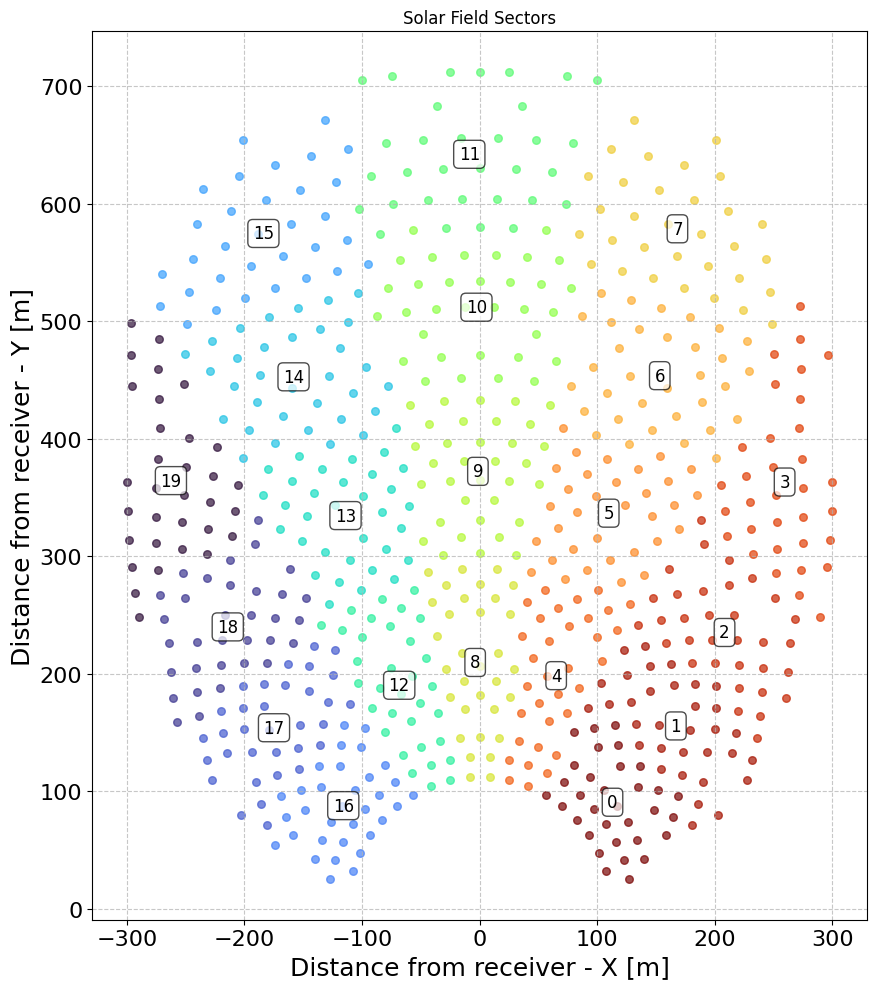

In [2]:
imodel = smf.SimplifiedFieldModel(file_params,file_SF, cleaning_rate=cleaning_rate)
sim_data = smb.SimulationInputs(file_weather,dust_type="PM10")
plant = smf.CentralTowerPlant()
plant.import_plant(file_params)
fig_sector_plot = imodel.helios.sector_plot(show_id=True)

In [3]:
imodel.sun_angles(sim_data)
imodel.helios_angles(plant,aoi_model=aoi_model,d=d)
imodel.calculate_delta_soiled_area(sim_data)

Calculating sun apparent movement and angles for 1 simulations


C:\Users\cholette\HelioSoil\src\heliosoil\base_models.py:1833: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  tg = np.array(time_grid.dt.to_pydatetime())
c:\Users\cholette\.virtualenvs\prometheus\lib\site-packages\pysolar\numeric.py:62: UserWarning: no explicit representation of timezones available for np.datetime64
  dd = numpy.array(d, dtype='datetime64[D]')
c:\Users\cholette\.virtualenvs\prometheus\lib\site-packages\pysolar\numeric.py:63: UserWarning: no explicit representation of timezones available for np.datetime64
  dy = numpy.array(d, dtype='datetime64[Y]')


Calculating heliostat movement and angles for 1 simulations
Second surface loss model
Calculating soil deposited in a timestep [m^2/m^2]


In [4]:
cleans = smu.simple_annual_cleaning_schedule(imodel.helios.tilt[0].shape[0],n_trucks,n_cleans,dt=sim_data.dt[0]/3600.00)
area_loss = imodel.reflectance_loss(sim_data,{0:cleans})

Calculating reflectance losses with cleaning for 1 simulations


In [5]:
soiling_factor = imodel.helios.soiling_factor[0] # zero for the first "run"
field_average_soiling_factor = np.mean(soiling_factor,axis=0)
imodel.optical_efficiency(plant,sim_data,climate_file,verbose=True,n_az=sun_az_num,n_el=sun_el_num)
field_average_clean_optical_efficiency = np.mean(imodel.helios.optical_efficiency[0]*imodel.helios.nominal_reflectance,axis=0)

Processing weather data as a TMY .csv file...


Computing grid - Power: 6.21e+04 kW (az=360.0°, el=90.0°): 100%|██████████| 100/100 [00:10<00:00,  9.12it/s]


Computing optical efficiency time series for file 0
Done!


In [6]:
soiled_optical_efficiency = imodel.helios.optical_efficiency[0]*soiling_factor*imodel.helios.nominal_reflectance
field_average_soiled_optical_efficiency = np.mean(soiled_optical_efficiency,axis=0)

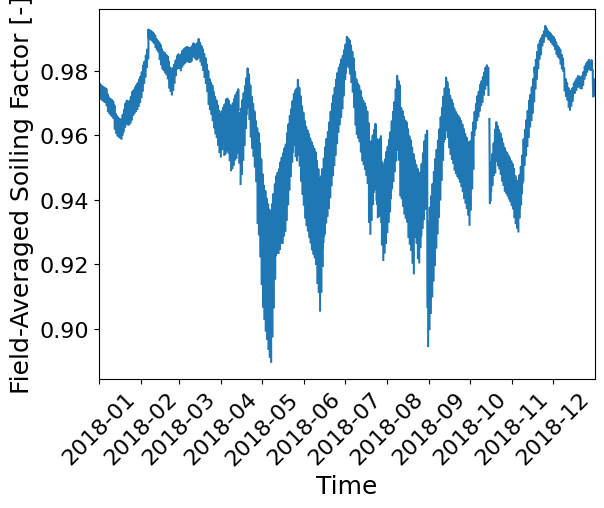

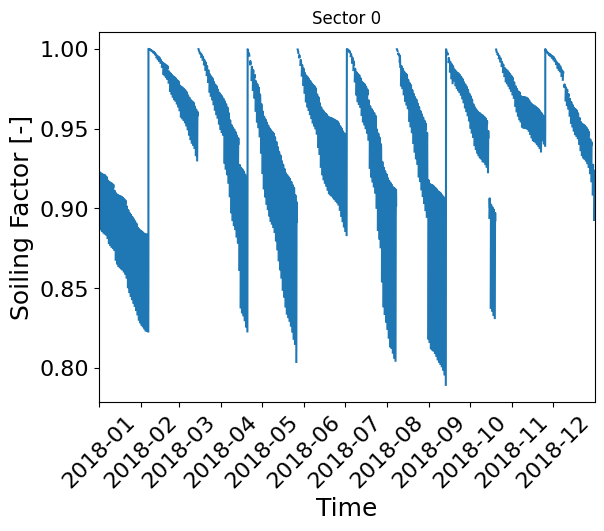

In [7]:
t = sim_data.time[0]
sec_plot = 0 # choose sector for plot

t0 = 0
t1 = t.index[-1] # hours of the year for the zoomed-in plot

# examine field soiling - field average
fig, ax = plt.subplots()
ax.plot(t,field_average_soiling_factor,"-")
ax.set_xlim(t[t0],t[t1])
ax.set_xlabel("Time")
ax.set_ylabel("Field-Averaged Soiling Factor [-]")
_, _ = plt.xticks(rotation=45)

# examine sector soiling 
fig, ax = plt.subplots()
ax.plot(t,soiling_factor[sec_plot],"-")
ax.set_xlim(t.iloc[0],t.iloc[-1])
ax.set_xlabel("Time")
ax.set_ylabel("Soiling Factor [-]")
ax.set_title("Sector {0:d}".format(sec_plot))
_, _= plt.xticks(rotation=45)

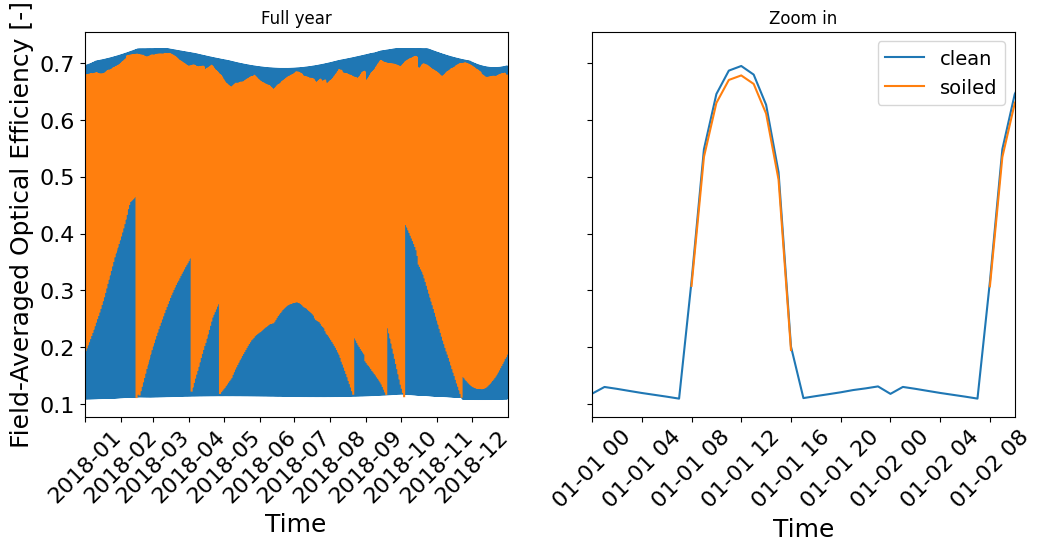

In [8]:
# examine optical efficiency - field average
t0 = 0
t1 = 24 # hours of the year for the zoomed-in plot

# t0 = 4000
# t1 = 4000+96 # hours of the year for the zoomed-in plot

fig, ax = plt.subplots(ncols=2,sharey=True,figsize=(12,5))
ax[0].plot(t,field_average_clean_optical_efficiency,"-",label='clean')
ax[0].plot(t,field_average_soiled_optical_efficiency,"-",label='soiled')
ax[0].set_xlim(t.iloc[0],t.iloc[-1])
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Field-Averaged Optical Efficiency [-]")
ax[0].set_title("Full year")
for label in ax[0].get_xticklabels():
    label.set(rotation=45)

ax[1].plot(t,field_average_clean_optical_efficiency,"-",label='clean')
ax[1].plot(t,field_average_soiled_optical_efficiency,"-",label='soiled')
ax[1].set_xlim(t[t0],t[t1+10])
ax[1].set_xlabel("Time")
ax[1].set_title("Zoom in")
_, _ = plt.xticks(rotation=45)
_ = plt.legend()

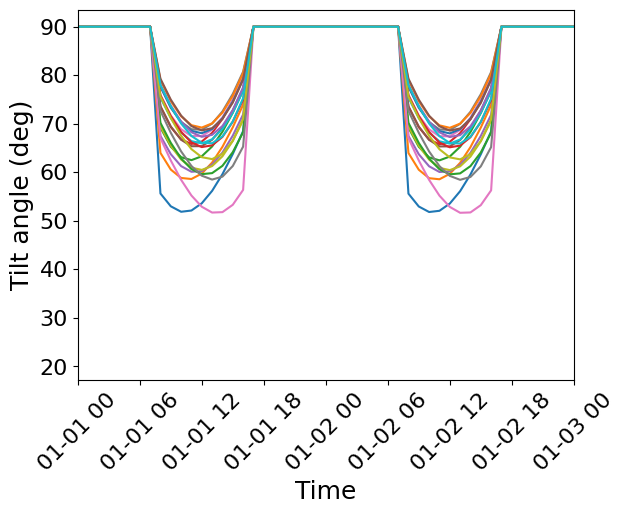

In [9]:
# examine tilts
h_start = 0
h_end = 48

Nhelios = imodel.helios.x.shape[0]
tilt = imodel.helios.tilt[0]
fig, ax = plt.subplots()
for h in range(Nhelios):
    ax.plot(t,tilt[h,:],"-")

ax.set_xlim(t[h_start],t[h_end])
_ = ax.set_xlabel("Time")
_ = ax.set_ylabel("Tilt angle (deg)")
_, _ = plt.xticks(rotation=45)

Calculating soil deposited in a timestep [m^2/m^2]


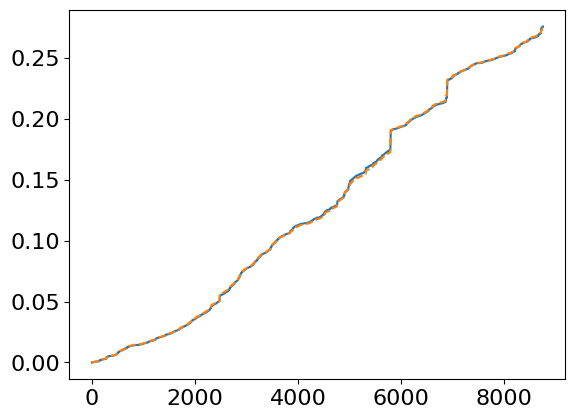

In [10]:
sim = imodel.random_delta_soiled_area(sim_data)
fig,ax = plt.subplots()
ax.plot(imodel.helios.delta_soiled_area[0].mean(axis=0).cumsum())
ax.plot(sim[0].mean(axis=0).cumsum(),ls='--')

Text(0.5, 1.0, 'Time at h = 5145 is 2018-08-03 09:00:00')

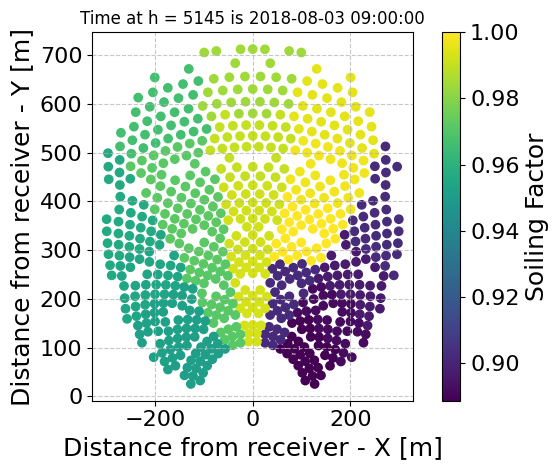

In [11]:
time_of_interest = pd.to_datetime('2018-08-03 09:00')
h = np.where(t==time_of_interest)[0][0]
fig,ax,dat = imodel.plot_soiling_factor(file=0,hour=h)
ax.set_title(f'Time at h = {h} is {sim_data.time[0][h]}')

In [12]:
df = pd.DataFrame({k:dat[k] for k in ['id','x','y','soiling_factor']})
df2 = pd.read_csv(file_SF,skiprows=[1])

In [13]:
num_match = 0
is_equal_x = lambda x: np.abs(x-df2["Loc. X"]) < 1e-10
is_equal_y = lambda y: np.abs(y-df2["Loc. Y"]) < 1e-10
is_equal_row = lambda r: is_equal_x(r.loc['x']) & is_equal_y(r.loc['y'])
sf = np.zeros(df2.shape[0])
for idx,row in df.iterrows():
    mask = is_equal_row(row)
    if sum(mask) != 1:
        raise IndexError(f"Exactly one heliostat position needs to match. Found {sum(mask):d}")
    else:
        sf[mask] = row['soiling_factor']

df2['soiling_factor_1'] = sf
df2

,Template,In layout,Enabled,Loc. X,Loc. Y,Loc. Z,X focus,Y focus,Cant vect.,Cant vect..1,Cant vect..2,Aim pt. X,Aim pt. Y,Aim pt. Z,soiling_factor_1
0,0,1,1,239.97,582.86,0,NaN,NaN,NaN,NaN,NaN,0,0,106.5,0.995444
1,0,1,1,-234.95,612.74,0,NaN,NaN,NaN,NaN,NaN,0,0,106.5,0.966793
2,0,1,1,295.88,291.29,0,NaN,NaN,NaN,NaN,NaN,0,0,106.5,0.902079
3,0,1,1,260.93,179.71,0,NaN,NaN,NaN,NaN,NaN,0,0,106.5,0.896460
4,0,1,1,296.25,471.03,0,NaN,NaN,NaN,NaN,NaN,0,0,106.5,0.902079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651,0,1,1,25.19,109.64,0,NaN,NaN,NaN,NaN,NaN,0,0,106.5,0.901979
652,0,1,1,-8.47,129.19,0,NaN,NaN,NaN,NaN,NaN,0,0,106.5,0.992980
653,0,1,1,-25.19,109.64,0,NaN,NaN,NaN,NaN,NaN,0,0,106.5,0.970867
654,0,1,1,8.46,112.18,0,NaN,NaN,NaN,NaN,NaN,0,0,106.5,0.992980


In [14]:
df2.to_excel(f'flat_dagget_50_soiling/{output_file}',sheet_name=(aoi_model+"_"+str(d)))

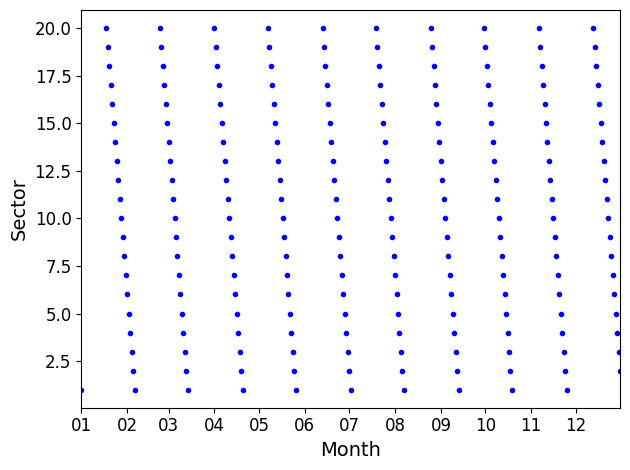

In [15]:
from matplotlib.dates import DateFormatter
n_sectors, n_timesteps = cleans.shape
time_daily = pd.to_datetime(sim_data.time[0]).dt.floor("D")
df_cleans = pd.DataFrame(cleans.T, index=time_daily).resample("D").max()
ax = plt.subplot()
for col in df_cleans.columns:
    mask = df_cleans[col] == 1
    ax.scatter(
        df_cleans.index[mask],
        df_cleans[col][mask] * int(col + 1),
        marker=".",
        color="blue",
        )

# Customize plot
ax.set_xlabel("Month", fontsize=14)
ax.set_ylabel("Sector", fontsize=14)
ax.set_xlim(df_cleans.index[0], df_cleans.index[-1])
ax.tick_params(axis="both", which="major", labelsize=12)
ax.xaxis.set_major_formatter(DateFormatter("%m"))

plt.tight_layout()